In [1]:
#!/usr/bin/env python
"""
fit the parameter in slater-isa force field with dmff backend 
"""

import time 
import optax
import sys 
import os 
import numpy as np

import jax
import jax.numpy as jnp
from jax import value_and_grad, vmap, jit

from openmm.app import PDBFile
from openmm.unit import angstrom
from openmm.app import CutoffPeriodic
from functools import partial
import pickle

# sys.path.append('/Users/jeremychen/Desktop/Project/project_electrolyte/test_hardcore_potential/DMFFsrdmp')
# sys.path.append('/Users/jeremychen/Desktop/Project/project_electrolyte/test_hardcore_potential/DMFFsrdmp_trainable')

from dmff.api import Hamiltonian
from dmff.utils import jit_condition
from dmff.common import nblist


In [2]:

class BasePairs:
    def __init__(self, ff, pdb, pdb_A, pdb_B):
        pdb = PDBFile(pdb)
        pdb_A = PDBFile(pdb_A)
        pdb_B = PDBFile(pdb_B)
        self.H = Hamiltonian(ff)
        self.H_A = Hamiltonian(ff)
        self.H_B = Hamiltonian(ff)
        self.pots = self.H.createPotential(pdb.topology, nonbondedCutoff=25*angstrom, nonbondedMethod=CutoffPeriodic, ethresh=1e-4, step_pol=20)
        self.generators = self.H.getGenerators()        
        self.pots_A = self.H_A.createPotential(pdb_A.topology, nonbondedCutoff=25*angstrom, nonbondedMethod=CutoffPeriodic, ethresh=1e-4, step_pol=20)
        self.generators_A = self.H_A.getGenerators()        
        self.pots_B = self.H_B.createPotential(pdb_B.topology, nonbondedCutoff=25*angstrom, nonbondedMethod=CutoffPeriodic, ethresh=1e-4, step_pol=20)
        self.generators_B = self.H_B.getGenerators()

        self.pos = jnp.array(pdb.positions._value)
        self.pos_A = jnp.array(pdb_A.positions._value)
        self.pos_B = jnp.array(pdb_B.positions._value)

        self.box = jnp.eye(3) * 6
        self.rc = 2.5
        self.nblist = nblist.NeighborList(self.box, self.rc, self.pots.meta['cov_map'])
        self.nblist_A = nblist.NeighborList(self.box, self.rc, self.pots_A.meta['cov_map'])
        self.nblist_B = nblist.NeighborList(self.box, self.rc, self.pots_B.meta['cov_map'])
        self.nblist.allocate(self.pos)
        self.nblist_A.allocate(self.pos_A)
        self.nblist_B.allocate(self.pos_B)
        self.pairs = self.nblist.pairs
        self.pairs_A = self.nblist_A.pairs
        self.pairs_B = self.nblist_B.pairs
        self.pairs_AB = self.pairs[self.pairs[:, 0] < self.pairs[:, 1]]
        self.pairs_A = self.pairs_A[self.pairs_A[:, 0] < self.pairs_A[:, 1]]
        self.pairs_B = self.pairs_B[self.pairs_B[:, 0] < self.pairs_B[:, 1]]

        self.potentials_names = ['es', 'disp']
        self.potentials_mapping = {
            'es': 'ADMPPmeForce',
            'disp': 'ADMPDispPmeForce',
        }
        
        for potentials_name in self.potentials_names:
            setattr(self, f'pots_{potentials_name}', self.pots.dmff_potentials[self.potentials_mapping[potentials_name]])
            setattr(self, f'pots_{potentials_name}_A', self.pots_A.dmff_potentials[self.potentials_mapping[potentials_name]])
            setattr(self, f'pots_{potentials_name}_B', self.pots_B.dmff_potentials[self.potentials_mapping[potentials_name]])

    def cal_E(self, params, pos_A, pos_B):
        # get position array
        pos_A *= 0.1
        pos_B *= 0.1
        pos_AB = jnp.concatenate([pos_A, pos_B], axis=0)
        box = self.box
        #####################
        # electrostatic + pol
        #####################
        E_espol_A = self.pots_es_A(pos_A, box, self.pairs_A, params)
        E_espol_B = self.pots_es_B(pos_B, box, self.pairs_B, params)
        E_espol = self.pots_es(pos_AB, box, self.pairs_AB, params) \
                    - E_espol_A \
                    - E_espol_B

        ###################################
        # use induced dipole of monomers to compute electrostatic interaction
        ###################################
        pme_generator_AB = self.generators[0]
        pme_generator_A = self.generators_A[0]
        pme_generator_B = self.generators_B[0]
        U_ind_AB = jnp.vstack((pme_generator_A.pme_force.U_ind, pme_generator_B.pme_force.U_ind))        
        params_pme = params['ADMPPmeForce']
        # map_atypes = pme_generator_AB.map_atomtype
        # map_poltypes = pme_generator_AB.map_poltype
        map_atypes = self.pots.meta['ADMPPmeForce_map_atomtype']
        map_poltypes = self.pots.meta['ADMPPmeForce_map_poltype']
        Q_local = params_pme['Q_local'][map_atypes]
        pol = params_pme['pol'][map_poltypes]
        tholes = params_pme['thole'][map_poltypes]
        pme_force = pme_generator_AB.pme_force
        E_nonpol_AB = pme_force.energy_fn(pos_AB*10, box*10, self.pairs_AB, Q_local, U_ind_AB, pol, tholes, \
                    pme_generator_AB.mScales, pme_generator_AB.pScales, pme_generator_AB.dScales)
        E_es = E_nonpol_AB - E_espol_A - E_espol_B

        ###################################
        # polarization (induction) energy
        ###################################
        E_pol = E_espol - E_es

        #############
        # dispersion
        #############
        E_disp = self.pots_disp(pos_AB, box, self.pairs_AB, params) \
                - self.pots_disp_A(pos_A, box, self.pairs_A, params) \
                - self.pots_disp_B(pos_B, box, self.pairs_B, params)

        return E_es, E_pol, E_disp


In [6]:
data_file = '/Users/jeremychen/Desktop/Project/project_electrolyte/test_hardcore_potential/20250721_try_modified_param_D/data_final_wt_lr_wt_lr.pickle'
data_file = 'data_train_final_wt_lr.pickle'
data_file = 'data_FSI_TFSI_bulk.pickle'
data_file = 'data_train_final_wt_lr_update_FSI.pickle'
data_file = 'data_train_final_wt_lr_update_FSI_wt_sr.pickle'
with open(data_file, 'rb') as ifile:
    data = pickle.load(ifile)


In [7]:
with open('data_NA_EC.pickle', 'rb') as ifile:
    data_Na_EC = pickle.load(ifile)

In [9]:
data['conf_071_Na_EC'] = data_Na_EC

In [10]:
# ff = 'output.2.ABC.solvents.pospenalty.25.LiNa.AexAes.new.xml'
# ff = 'test_Li_EC.xml'
# ff = 'forcefield_EC_Li.xml'
ff = 'output_xml/output.salts.nolim0.xml'
ff = 'output_xml/output.salts.nolim0.xml'
# ff = '/Users/jeremychen/Desktop/Project/project_electrolyte/lr_param-dep-conf/forcefield/phyneo_ecl_wt_peo.xml'
params = Hamiltonian(ff).getParameters()


In [11]:

arr = ['DEC', 'DFEA', 'DFEC', 'DMC', 'DME', 'DOL', 'EC', 'EMC', 'EP', \
        'FEC', 'FEMC', 'GBL', 'PC', 'PP', 'PS', 'SL',]# 'CN1', 'CN2',]

def get_all_homo_key(data, arr):
    dimer_test = []
    for key in data:
        a, b = key.split('_')[-2:]
        if a == b and b in arr:
            dimer_test.append(key)
        else:
            continue
    return dimer_test
def get_all_contain_key(data, arr):
    dimer_test = []
    for key in data:
        a, b = key.split('_')[-2:]
        if a in arr or b in arr:
            if b != 'CN1' and b != 'CN2':
                dimer_test.append(key)
        else:
            continue
    return dimer_test
# dimer_train = get_all_contain_key(data, ['Na'])
dimer_train = get_all_contain_key(data, ['PF6'])
# dimer_train = get_all_homo_key(data, ['FEMC'])

# dimer_train = get_all_homo_key(data, arr)
# dimer_train = ['conf_053_Li_FSI']
# dimer_train = ['conf_062_Li_EC']
# dimer_train = ['conf_053_Li_FSI']
# dimer_train = ['conf_053_Li_FSI']
# dimer_train = ['conf_053_Li_FSI']
# dimer_train = ['conf_063_Li_EMC']
dimer_train = ['conf_071_Na_EC']
# dimer_train = list(data.keys())
dimer_train.sort()
print(len(dimer_train), dimer_train)

1 ['conf_071_Na_EC']


In [12]:
data.keys()

dict_keys(['conf_000_DEC_DEC', 'conf_001_DMC_DMC', 'conf_002_DME_DME', 'conf_003_EC_EC', 'conf_004_EMC_EMC', 'conf_005_FEC_FEC', 'conf_006_PC_PC', 'conf_007_PP_PP', 'conf_008_PS_PS', 'conf_009_DEC_DMC', 'conf_010_DEC_DME', 'conf_011_DEC_EC', 'conf_012_DEC_EMC', 'conf_013_DEC_FEC', 'conf_014_DEC_PC', 'conf_015_DEC_PP', 'conf_016_DEC_PS', 'conf_017_DMC_DME', 'conf_018_DMC_EC', 'conf_019_DMC_EMC', 'conf_020_DMC_FEC', 'conf_021_DMC_PC', 'conf_022_DMC_PP', 'conf_023_DMC_PS', 'conf_024_DME_EC', 'conf_025_DME_EMC', 'conf_026_DME_FEC', 'conf_027_DME_PC', 'conf_028_DME_PP', 'conf_029_DME_PS', 'conf_030_EC_EMC', 'conf_031_EC_FEC', 'conf_032_EC_PC', 'conf_033_EC_PP', 'conf_034_EC_PS', 'conf_035_EMC_FEC', 'conf_036_EMC_PC', 'conf_037_EMC_PP', 'conf_038_EMC_PS', 'conf_039_FEC_PC', 'conf_040_FEC_PP', 'conf_041_FEC_PS', 'conf_042_PC_PP', 'conf_043_PC_PS', 'conf_044_PP_PS', 'conf_048_BOB_BOB', 'conf_049_FSI_FSI', 'conf_086_BOB_DEC', 'conf_087_BOB_DMC', 'conf_088_BOB_DME', 'conf_089_BOB_EC', 'conf_090_

In [13]:
# dimer_train = list(data.keys())
# dimer_train = ['conf_062_Li_EC']
dimer_train.sort()
# Loop to create subclasses and add them to the global namespace
class_instances = {}
for pair in dimer_train: 
    conf, numb_conf, monomer_A, monomer_B = pair.split('_')
    dimer_file = f'dimer_{numb_conf}_{monomer_A}_{monomer_B}'
    dimer_file = f'dimer_bank/{dimer_file}.pdb'
    pdb_A_file = f'pdb_bank/{monomer_A}.pdb'
    pdb_B_file = f'pdb_bank/{monomer_B}.pdb'
    class_instances[pair] = BasePairs(ff, dimer_file, pdb_A_file, pdb_B_file)
cal_energy = {}
for class_name, class_instance in class_instances.items():
    cal_energy[class_name] = jit(vmap(class_instance.cal_E, in_axes=(None, 0, 0), out_axes=(0, 0, 0)))


In [14]:
# for sapt-dft or other energy decompostion analysis methods
for key in dimer_train:

    batch = list(data[key].keys())[0]
    # batch = '000'
    E_es, E_pol, E_disp = cal_energy[key](params, jnp.array(data[key][batch]['posA']), jnp.array(data[key][batch]['posB']))
    print(key, E_es[0], E_pol[0], E_disp[0])

    for sid in data[key].keys():
        scan_res = data[key][sid]
        if 'tot_full' not in scan_res.keys():
            scan_res['tot_full'] = scan_res['tot'].copy()

        npts = len(scan_res['tot'])

        # Calculate energy values
        E_es, E_pol, E_disp = cal_energy[key](params, scan_res['posA'], scan_res['posB'])
        
        if 'lr_tot' not in scan_res.keys():
            scan_res['lr_tot'] = E_es + E_pol + E_disp
            scan_res['lr_es'] = E_es
            scan_res['lr_pol'] = E_pol
            scan_res['lr_disp'] = E_disp
            scan_res['tot'] -= E_es + E_pol + E_disp
            scan_res['es'] -= E_es
            scan_res['pol'] -= E_pol
            scan_res['disp'] -= E_disp
        else:
            scan_res['tot'] += scan_res['lr_tot']
            scan_res['es'] += scan_res['lr_es']
            scan_res['pol'] += scan_res['lr_pol']
            scan_res['disp'] += scan_res['lr_disp']
            scan_res['lr_tot'] = E_es + E_pol + E_disp
            scan_res['lr_es'] = E_es
            scan_res['lr_pol'] = E_pol
            scan_res['lr_disp'] = E_disp
            scan_res['tot'] -= E_es + E_pol + E_disp
            scan_res['es'] -= E_es
            scan_res['pol'] -= E_pol
            scan_res['disp'] -= E_disp            

    # Save the updated data to a pickle file
    # data_label = data_file.split('.')[0]
    # with open(f'data_FSI_TFSI_wt_lr.pickle', 'wb') as ofile:
    #     pickle.dump(data, ofile)

conf_071_Na_EC -244.8333823191245 -243.25362952337764 -108.01096195521018


In [15]:
data_file = 'data_train_final_wt_lr_update_FSI_wt_sr.pickle'
print(data_file)
with open(data_file, 'wb') as ofile:
    pickle.dump(data, ofile)

data_train_final_wt_lr_update_FSI_wt_sr.pickle


In [10]:
def plot_sapt_ff_multi_y(key, scan_res, batch):
    import matplotlib.pyplot as plt

    sapt_es = scan_res['es'] + scan_res['lr_es']
    sapt_pol = scan_res['pol'] + scan_res['lr_pol']
    sapt_disp = scan_res['disp'] + scan_res['lr_disp']
    sapt_tot = scan_res['tot_full']
    dist = scan_res['shift']

    ff_es = scan_res['lr_es']
    ff_pol = scan_res['lr_pol']
    ff_disp = scan_res['lr_disp']
    ff_lr = scan_res['lr_tot']

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    labels = ['Total', 'Electrostatics', 'Polarization', 'Dispersion']
    sapt_data = [sapt_tot, sapt_es, sapt_pol, sapt_disp]
    ff_data = [ff_lr, ff_es, ff_pol, ff_disp]

    fig, ax = plt.subplots(figsize=(10, 5))
    axes = [ax]
    for i in range(1, 4):
        axes.append(ax.twinx())
        axes[-1].spines['right'].set_position(('outward', 60 * (i - 1)))

    for i, (label, color) in enumerate(zip(labels, colors)):
        axes[i].plot(dist, sapt_data[i], label=f'{label} (SAPT)', marker='x', color=color, linestyle='--', linewidth=2, markersize=5)
        axes[i].plot(dist, ff_data[i], label=f'{label} (FFs)', marker='o', color=color, linewidth=2, markersize=5)

        axes[i].set_ylabel(f'{label} Energy (kJ/mol)', fontsize=12)
        axes[i].tick_params(axis='y', colors=color)
        axes[i].spines['right' if i > 0 else 'left'].set_color(color)

    ax.set_xlabel('Distance (Å)', fontsize=12)
    ax.set_title(f'{key} {batch} Average Params', fontsize=14, pad=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right', fontsize=10)

    fig.tight_layout()
    # save_path = f'results_lr/plot_long-range_{key}.png'
    save_path = f'results_lr/plot_long-range_{key}_{batch}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


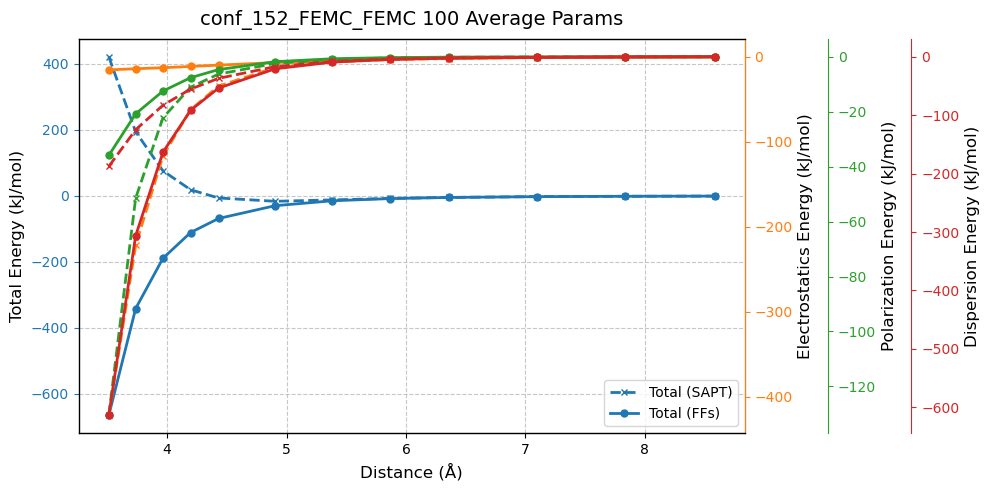

In [11]:
# for key in ['conf_051_Li_PF6']:
for key in dimer_train:
    batch = '100'
    scan_res = data[key][batch]
    sapt_es = scan_res['es'] + scan_res['lr_es']
    sapt_pol = scan_res['pol'] + scan_res['lr_pol']
    sapt_disp = scan_res['disp'] + scan_res['lr_disp']
    sapt_tot = scan_res['tot_full']
    dist = np.linalg.norm(np.mean(scan_res['posA'],axis=1) - np.mean(scan_res['posB'],axis=1), axis=1)
    # dist = scan_res['shift']
    scan_res['shift'] = dist

    ff_es = scan_res['lr_es']
    ff_pol = scan_res['lr_pol']
    ff_disp = scan_res['lr_disp']
    ff_lr = scan_res['lr_tot']
    plot_sapt_ff_multi_y(key, scan_res, batch)

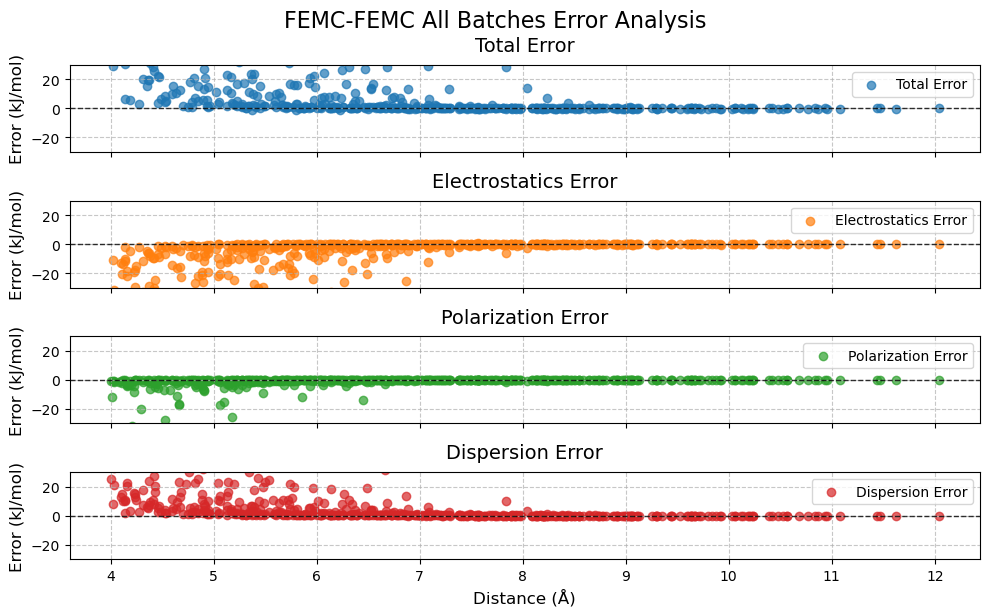

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_batches_error_subplots(data, dimer_train):
    for key in dimer_train:
        all_batches = data[key].keys()
        combined_data = {
            'dist': [],
            'error_es': [],
            'error_pol': [],
            'error_disp': [],
            'error_tot': []
        }

        for batch in all_batches:
            scan_res = data[key][batch]
            sapt_es = scan_res['es'] + scan_res['lr_es']
            sapt_pol = scan_res['pol'] + scan_res['lr_pol']
            sapt_disp = scan_res['disp'] + scan_res['lr_disp']
            sapt_tot = scan_res['tot_full']
            dist = np.linalg.norm(np.mean(scan_res['posA'], axis=1) - np.mean(scan_res['posB'], axis=1), axis=1)

            ff_es = scan_res['lr_es']
            ff_pol = scan_res['lr_pol']
            ff_disp = scan_res['lr_disp']
            ff_tot = scan_res['lr_tot']

            error_es = sapt_es - ff_es
            error_pol = sapt_pol - ff_pol
            error_disp = sapt_disp - ff_disp
            error_tot = sapt_tot - ff_tot

            # Filter points with distance less than 4Å
            mask = dist > 4.0
            combined_data['dist'].extend(dist[mask])
            combined_data['error_es'].extend(error_es[mask])
            combined_data['error_pol'].extend(error_pol[mask])
            combined_data['error_disp'].extend(error_disp[mask])
            combined_data['error_tot'].extend(error_tot[mask])

        # Plotting
        fig, axs = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
        errors = ['error_tot', 'error_es', 'error_pol', 'error_disp']
        titles = ['Total Error', 'Electrostatics Error', 'Polarization Error', 'Dispersion Error']
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

        for i, ax in enumerate(axs):
            ax.scatter(combined_data['dist'], combined_data[errors[i]], label=titles[i], color=colors[i], alpha=0.7)
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.8)  # Add y=0 line
            ax.set_ylim(-30, 30)  # Set y-axis limits
            ax.set_ylabel('Error (kJ/mol)', fontsize=12)
            ax.set_title(titles[i], fontsize=14, pad=10)
            ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend(fontsize=10)

        axs[-1].set_xlabel('Distance (Å)', fontsize=12)
        plt.tight_layout()
        plt.suptitle(f'{key.split("_")[-2]}-{key.split("_")[-1]} All Batches Error Analysis', fontsize=16, y=1.02)
        save_path = f'results_lr/plot_long-range_error_subplots_{key}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

# Example usage:
plot_all_batches_error_subplots(data, dimer_train)

In [13]:
with open('data_train_final_wt_lr.pickle', 'rb') as ofile:
    data_all = pickle.load(ofile)

In [14]:
data_all[key]['000'].keys()

dict_keys(['shift', 'es', 'ex', 'pol', 'dhf', 'disp', 'tot', 'posA', 'posB', 'wts', 'tot_full', 'lr_es', 'lr_pol', 'lr_disp', 'lr_tot'])

In [ ]:
for key in dimer_train:
    print(key)
    data_all[key] = data[key]
with open(f'data_train_final_wt_lr_update_FSI.pickle', 'wb') as ofile:
    pickle.dump(data_all, ofile)

conf_053_Li_FSI
conf_054_Li_TFSI
conf_057_Na_FSI
conf_058_Na_TFSI


In [19]:
key

'conf_053_Li_FSI'

In [27]:
data_all['conf_051_Li_PF6']['000']['lr_es']

Array([-532.27639119, -565.9567245 , -559.53522153, -535.23364884,
       -504.4862771 , -442.36168792, -388.75426615, -344.85922022,
       -309.08606695, -266.8952098 , -234.5644813 , -209.10937671],      dtype=float64)

In [26]:
data_all['conf_051_Li_PF6']['000']['es']

Array([32.37215536, 20.16680751, 11.42517514,  5.49231583,  1.89237451,
       -1.13162873, -1.81183493, -1.81122045, -1.62343622, -1.33358048,
       -1.122683  , -0.96981641], dtype=float64)

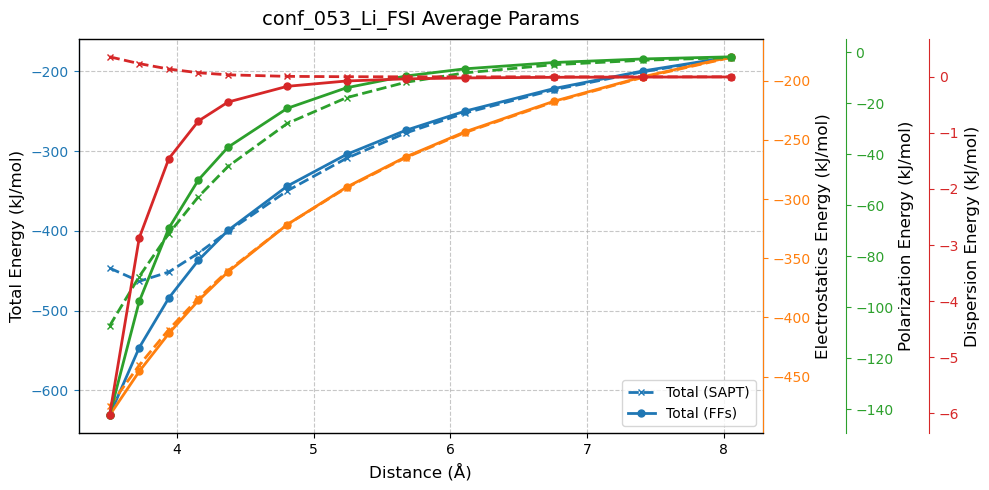

In [18]:
for key in ['conf_053_Li_FSI']:
# for key in dimer_train:
    batch = '000'
    scan_res = data_all[key][batch]
    sapt_es = scan_res['es'] + scan_res['lr_es']
    sapt_pol = scan_res['pol'] + scan_res['lr_pol']
    sapt_disp = scan_res['disp'] + scan_res['lr_disp']
    sapt_tot = scan_res['tot_full']
    dist = np.linalg.norm(np.mean(scan_res['posA'],axis=1) - np.mean(scan_res['posB'],axis=1), axis=1)
    # dist = scan_res['shift']
    scan_res['shift'] = dist

    ff_es = scan_res['lr_es']
    ff_pol = scan_res['lr_pol']
    ff_disp = scan_res['lr_disp']
    ff_lr = scan_res['lr_tot']
    plot_sapt_ff_multi_y(key, scan_res)

In [2]:
key = 'conf_062_Li_EC'
batch = '000'
scan_res = data_all[key][batch]
print(scan_res['posA'][5])
print(scan_res['posB'][5])


NameError: name 'data_all' is not defined

In [ ]:
# tot = scan_res['tot'] + scan_res['lr_tot']
# es = scan_res['es'] + scan_res['lr_es']
# pol = scan_res['pol'] + scan_res['lr_pol']
# disp = scan_res['disp'] + scan_res['lr_disp']
# ex = scan_res['ex']
# dhf = scan_res['dhf']

# print('tot', tot[5])
# print('es', es[5])
# print('pol', pol[5])
# print('disp', disp[5])
# print('ex', ex[5])
# print('dhf', dhf[5])

In [ ]:
# #! SAPT(DFT) aug-cc-pVDZ interaction energy between Ne and Ar atoms.

# # Note: Delta HF is turned off in this test, because the delta HF calculation is in the run_sapt_dft() call, while the purpose of this test is to verify the results of the sapt_dft() call.




# molecule dimer {
# 1 1
# Li,,13.45899963,18.78300095,18.50000000
# --
# 0 1
# O,,14.08774281,18.47158241,15.43483257
# C,,14.40074253,18.02258301,14.33983231
# O,,14.15074253,18.75358391,13.17683220
# C,,14.51874256,18.00158310,12.08883190
# C,,14.82974339,16.56758308,12.57583237
# O,,14.79174328,16.80358315,14.01283264
# H,,15.44874287,18.37058258,11.63683224
# H,,13.72674274,17.96258354,11.41483212
# H,,15.90274334,16.31458282,12.24983215
# H,,14.12474346,15.78158474,12.19883251
# units angstrom
# }

# # Set options
# set {
#     basis         aug-cc-pvdz
#     e_convergence 1e-8
#     d_convergence 1e-8
#     sapt_dft_grac_shift_a 0.403106
#     sapt_dft_grac_shift_b 0.100020
#     SAPT_DFT_FUNCTIONAL PBE0
#     SAPT_DFT_MP2_DISP_ALG FISAPT
# }

# # No hybrid kernel & no exch-disp scaling & no delta HF
# set SAPT_DFT_DO_DHF False
# set SAPT_DFT_DO_HYBRID False
# set SAPT_DFT_EXCH_DISP_SCALE_SCHEME none
# energy('sapt(dft)', molecule=dimer)
